# Stamp and Signature Detection Benchmark

This notebook implements a pipeline to train, evaluate, and benchmark YOLOv8 models for document stamp and signature detection. It contains data ingestion, dataset configuration fixes, training for small/medium counterparts, and performance evaluation.

In [1]:
# Install required packages
%pip install roboflow ultralytics pyyaml

## 1. Data Setup & Ingestion

Downloading the dataset straight from Roboflow and adjusting the internal YAML configuration so that Ultralytics uses correct relative paths.

In [2]:
import os
import yaml
import subprocess
#to download the dataset from the website into the notebook directly register->export->data snippet
#link: https://universe.roboflow.com/edvard-khalafyan-x1z6v/idp_stamp_signature_detection
print("Downloading dataset...")
os.system('curl -L "personal link" > roboflow.zip')
os.system('unzip -o roboflow.zip && rm roboflow.zip')
print("Download complete.")

dataset_location = os.path.abspath(".")

def fix_yaml_paths(dataset_path):
    yaml_path = os.path.join(dataset_path, "data.yaml")
    if not os.path.exists(yaml_path):
        print(f"Error: {yaml_path} not found.")
        return yaml_path
    
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)
        
    data['path'] = os.path.abspath(dataset_path)
    
    has_train = os.path.exists(os.path.join(dataset_path, "train"))
    has_valid = os.path.exists(os.path.join(dataset_path, "valid"))
    has_test = os.path.exists(os.path.join(dataset_path, "test"))
    
    data['train'] = "train/images" if has_train else ""
    data['val'] = "valid/images" if has_valid else "train/images"
    
    if 'test' in data:
        data['test'] = "test/images" if has_test else "train/images"
        
    with open(yaml_path, 'w') as f:
        yaml.dump(data, f, sort_keys=False)
    
    print(f"Updated paths in {yaml_path}.")
    return yaml_path

data_yaml = fix_yaml_paths(dataset_location)

Download complete.
Updated paths in /content/data.yaml.


## 2. Model Training (YOLOv8s & YOLOv8m)

This section systematically trains the Small (yolov8s.pt) and Medium (yolov8m.pt) variants.
Early stopping is utilized (patience=15) and standard hyperparameters are kept consistent.

In [3]:
import torch
from ultralytics import YOLO

if not torch.cuda.is_available():
    print("Warning: No GPU detected. Using CPU.")
else:
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")

def train_model(model_name, config_yaml):
    print(f"Training {model_name}...")
    model = YOLO(model_name)
    
    selected_device = 0 if torch.cuda.is_available() else "cpu"
    
    results = model.train(
        data=config_yaml,
        epochs=3,
        patience=15,    
        imgsz=640,
        batch=16,
        device=selected_device,
        project="benchmarks",
        name=model_name.replace(".pt", "")
    )
    return model, results

model_small, _ = train_model("yolov8s.pt", data_yaml)
model_medium, _ = train_model("yolov8m.pt", data_yaml)

trained_models = {
    "yolov8s": model_small,
    "yolov8m": model_medium
}

Using GPU: Tesla T4
Training yolov8s.pt...
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, 

## 3. Evaluation & Inference Benchmark

Using the test data split to map precision, recall, and end-to-end inference latency thresholds.

In [16]:
import os
import yaml
import glob

print("Downloading new validation/test dataset...")
os.system('curl -L "personal link" > test_data.zip')
os.system('unzip -o test_data.zip -d test_dataset && rm test_data.zip')
print("Download complete.")

new_dataset_location = os.path.abspath("test_dataset")
new_data_yaml = os.path.join(new_dataset_location, "data.yaml")

if os.path.exists(new_data_yaml):
    with open(new_data_yaml, 'r') as f:
        config = yaml.safe_load(f)
    
    config['path'] = new_dataset_location
    
    # Use glob to dynamically find image directories
    # Roboflow sometimes exports as valid/images, val/images, test/images, or just images/
    found_img_dirs = []
    for root, dirs, files in os.walk(new_dataset_location):
        if 'images' in dirs:
            rel_path = os.path.relpath(os.path.join(root, 'images'), new_dataset_location)
            found_img_dirs.append(rel_path.replace('\\', '/'))
            
    print(f"Found image directories: {found_img_dirs}")
    
    # Assign robustly
    test_cand = next((p for p in found_img_dirs if 'test' in p.lower()), None)
    val_cand = next((p for p in found_img_dirs if 'val' in p.lower()), None)
    train_cand = next((p for p in found_img_dirs if 'train' in p.lower()), None)
    
    # Fallbacks if specific subsets are missing
    if not val_cand and test_cand: val_cand = test_cand
    if not val_cand and train_cand: val_cand = train_cand
    if not val_cand and found_img_dirs: val_cand = found_img_dirs[0]
    
    config['val'] = val_cand or ""
    if test_cand:
        config['test'] = test_cand
    elif 'test' in config:
        del config['test']
        
    if train_cand:
        config['train'] = train_cand
    elif 'train' in config:
        del config['train']

    print(f"Using splits -> val: {config.get('val')}, test: {config.get('test')}, train: {config.get('train')}")

    with open(new_data_yaml, 'w') as f:
        yaml.dump(config, f, sort_keys=False)
    
    print(f"Updated paths in {new_data_yaml}.")
else:
    print("Warning: validation dataset data.yaml not found.")


Download complete.
Found image directories: ['train/images']
Using splits -> val: train/images, test: None, train: train/images
Updated paths in /content/test_dataset/data.yaml.


In [17]:
metrics_block = {}

eval_yaml = new_data_yaml if os.path.exists(new_data_yaml) else data_yaml

for target_id, engine in trained_models.items():
    print(f"Evaluating {target_id}...")
    # Ultralytics automatically refers to the 'val' key in data.yaml when no split is specified.
    metrics = engine.val(data=eval_yaml)
    
    mAP50 = metrics.box.map50
    mAP50_95 = metrics.box.map
    speed_latency = metrics.speed['inference'] if 'inference' in metrics.speed else 0.0
    
    metrics_block[target_id] = {
        "mAP@50": mAP50,
        "mAP@50-95": mAP50_95,
        "Inference Latency (ms/img)": speed_latency
    }

print("\nBenchmark Results:")
for target_id, stats in metrics_block.items():
    print(f"[{target_id}]")
    print(f"  mAP@50:         {stats['mAP@50']:.4f}")
    print(f"  mAP@50-95:      {stats['mAP@50-95']:.4f}")
    print(f"  Speed (ms/img): {stats['Inference Latency (ms/img)']:.2f} ms")

Evaluating yolov8s...
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1993.0±833.6 MB/s, size: 325.3 KB)
val: Scanning /content/test_dataset/train/labels... 125 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 125/125 2.2Kit/s 0.1s
val: New cache created: /content/test_dataset/train/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.5it/s 5.4s0.3ss
                   all        125        341      0.895      0.873      0.912      0.693
             signature        123        212      0.806      0.755      0.835      0.503
                 stamp        103        129      0.985      0.991      0.989      0.884
Speed: 4.5ms preprocess, 8.7ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to /content/runs/detect/val-11
Evaluating yolov8m...
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla 

## 4. Visual Cross-Model Assessment

Processes raw test images and builds output directories holding annotated inferences to compare Small vs Medium bounding box accuracies qualitatively.

In [18]:
import os
print(os.listdir("/content"))

['.config', 'runs', 'train', 'README.roboflow.txt', 'test_dataset', 'data.yaml', 'yolo26n.pt', 'yolov8m.pt', 'yolov8s.pt', 'sample_data']


In [19]:
import shutil
import glob

# Dynamically find the images directory we want to run inference on
target_dir_base = new_dataset_location if os.path.exists(new_dataset_location) else dataset_location

test_images_dir = None
for root, dirs, files in os.walk(target_dir_base):
    if 'images' in dirs:
        test_images_dir = os.path.join(root, 'images')
        # Prefer 'test' or 'val' over 'train'
        if 'test' in root.lower() or 'val' in root.lower() or 'valid' in root.lower():
            break

if test_images_dir and os.path.exists(test_images_dir):
    print(f"Running inference on validation directory: {test_images_dir}...")
    for target_id, engine in trained_models.items():
        out_dir = f"inference_output/{target_id}"
        os.makedirs(out_dir, exist_ok=True)
        
        print(f"Processing with {target_id}...")
        engine.predict(source=test_images_dir, save=True, project="inference_output", name=target_id, exist_ok=True)
        print(f"Saved outputs to {out_dir}")
else:
    print(f"Warning: Assessment image directory not found in {target_dir_base}")

Running inference on validation directory: /content/test_dataset/train/images...
Processing with yolov8s...

image 1/125 /content/test_dataset/train/images/0180289--1-_jpg.rf.rB3ykPJWAWYrfCUDZKWD.jpg: 640x480 1 signature, 1 stamp, 69.3ms
image 2/125 /content/test_dataset/train/images/04ed76f9aa72894d3ec6c3f2c23ac74e--1-_jpg.rf.awudmmNwfIhoA4dAX0wB.jpg: 640x480 1 signature, 1 stamp, 12.1ms
image 3/125 /content/test_dataset/train/images/06_10_2018--1-_jpg.rf.oojVwLzWGvFFFZfyGA8q.jpg: 640x480 1 stamp, 12.1ms
image 4/125 /content/test_dataset/train/images/08755677--1-_jpg.rf.Pzcn4xGBZO74HlGgoUOg.jpg: 640x480 1 signature, 1 stamp, 12.6ms
image 5/125 /content/test_dataset/train/images/1231--5-_jpg.rf.NBkboUvI1lxtkKK5Qxi5.jpg: 640x480 1 signature, 1 stamp, 12.0ms
image 6/125 /content/test_dataset/train/images/12960-300--1-_jpg.rf.ndjZhJ4u7LxqJxn9xKI7.jpg: 640x480 2 signatures, 2 stamps, 12.1ms
image 7/125 /content/test_dataset/train/images/1417--1-_jpg.rf.Z2aWWGfQ7SvUUTZWCFH3.jpg: 640x480 1 s

## 5. Performance Visualizations

Plotting the accuracy metrics (mAP@50 and mAP@50-95) alongside inference latency to visually assess the tradeoffs across models.

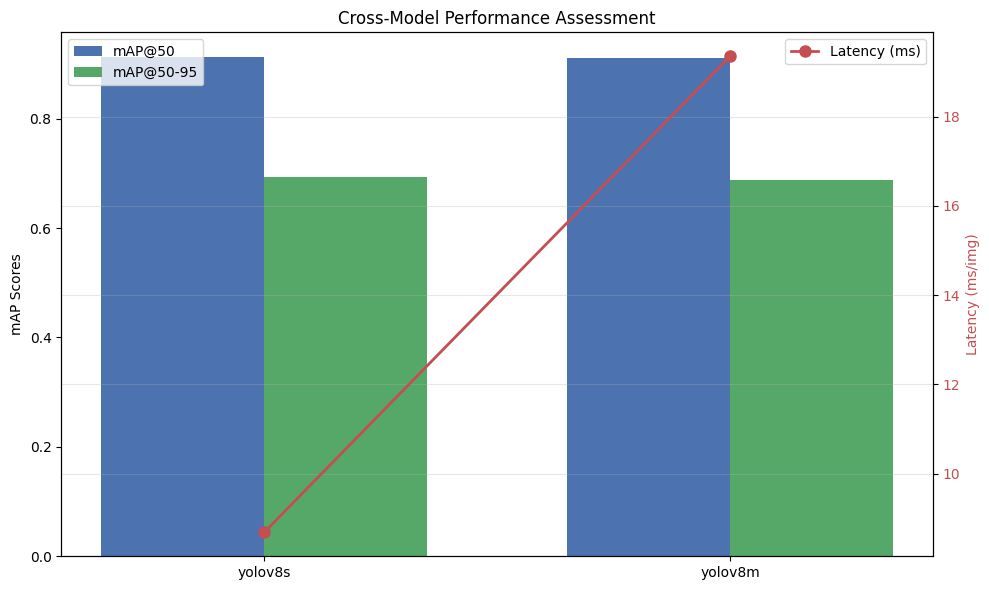

In [20]:
import matplotlib.pyplot as plt
import numpy as np

models = list(metrics_block.keys())
map50 = [metrics_block[m]["mAP@50"] for m in models]
map50_95 = [metrics_block[m]["mAP@50-95"] for m in models]
latency = [metrics_block[m]["Inference Latency (ms/img)"] for m in models]

x = np.arange(len(models))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(x - width/2, map50, width, label='mAP@50', color='#4C72B0')
ax1.bar(x + width/2, map50_95, width, label='mAP@50-95', color='#55A868')
ax1.set_ylabel('mAP Scores')
ax1.set_title('Cross-Model Performance Assessment')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(x, latency, color='#C44E52', marker='o', linestyle='-', linewidth=2, markersize=8, label='Latency (ms)')
ax2.set_ylabel('Latency (ms/img)', color='#C44E52')
ax2.tick_params(axis='y', labelcolor='#C44E52')
ax2.legend(loc='upper right')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()